# Project B Code:

### All the data analysis for the DBR laser linewidth, polarisation spectroscopy and MOT thermometry. 

## Part 1: Laser Linewidth Measurement

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import axes3d

import scipy
import scipy.special as sp
from scipy import *
from scipy.signal import find_peaks
from scipy.integrate import quad, dblquad
from scipy.special import erf
import scipy.interpolate as interpolate
from scipy.optimize import curve_fit
from scipy.signal import butter, filtfilt, windows, detrend
from scipy.signal import savgol_filter

import pandas as pd
import math
import cmath
import os
import datetime



In [ ]:
class LaserMeasurement:

    def __init__(self,filename):
        self.filename = filename
    
    def oscilloscope_data(self, 
                          plot = True, 
                          figsize = (12,8),
                          font_family = 'Arial',
                          save_fig = True, 
                          save_fig_name = None):
        # Reading data with pandas, ensuring numeric conversion
        df = pd.read_csv(self.filename,skiprows=11,names = ['TIME','CH1'])
        
        # Validate datafram structure
        if 'TIME' not in df.columns or 'CH1' not in df.columns:
            print("Invalid CSV structure")
            return np.array([]),np.array([])
        
        # Convert to numeric and force errors to NaN
        time_series = pd.to_numeric(df['TIME'], errors = 'coerce')
        volts_series = pd.to_numeric(df['CH1'], errors = 'coerce')
        
        # Checking for NaN points
        if time_series.isna().all() or volts_series.isna().all():
            print("Numeric conversion failed for all data")
            return np.array([]), np.array([])
        
        time = time_series.values
        volts = volts_series.values
       
        # Remove any NaN values present
        valid_mask = ~(np.isnan(time) | np.isnan(volts))
        time = time[valid_mask]
        volts = volts[valid_mask]

        volts_raw = volts
        volts_clean = volts_raw - np.mean(volts_raw)

        # Final Validation
        if len(time) == 0 or len(volts) == 0:
            print("No valid data found after filtering")
            return np.array([]),np.array([])
        
        assert len(time) == len(volts)
        
        # -------- DETERMINING BEAT FREQUENCY ------------ 

        # FFT Initialisation
        dt = time[1] - time[0]
        N = len(volts_clean)
    
        # FFT Implementation for positive frequencies only
        fft_data = np.fft.fft(volts_clean)
        freqs = np.fft.fftfreq(N, dt)
        
        mask = freqs > 0
        freqs_mhz = freqs[mask] * 1e-6
        spectrum = np.abs(fft_data[mask])
        spectrum /= np.max(spectrum)
        
        # Identify main beat peak
        peak_index = np.argmax(spectrum)
        peak_freq = freqs_mhz[peak_index] #  *This* is the beat frequency

        #-----------------------------------------------
        
        if plot:

            plt.figure(figsize= figsize)
            plt.grid(True, alpha = 0.1)
            plt.rcParams['font.family'] = font_family
            title_size = 30
            lab_size = legend_size = 25
            xtick_size = ytick_size = 22.5
            lw = 1.0
            pad = 20

            plt.plot(time * 1e6, volts_clean * 1e3,  'b-', linewidth = lw) # , label='Clean Signal', linewidth=2)
            # plt.title(fr'Oscilloscope data for $\Delta f$ = {peak_freq:.3f} MHz', size = title_size)
            plt.xlabel(r'time, $\mu$s', size = lab_size, labelpad= pad)
            plt.xticks(size = xtick_size)
            plt.ylabel(r'Voltage, mV', size = lab_size, labelpad= pad)
            plt.yticks(size = ytick_size)
            
            plt.xlim([-1.0,1.0])
            plt.legend(fontsize =legend_size)
            plt.tight_layout()

            if save_fig:
                if save_fig_name is None:
                    # Generate timestamp with year-month-day and seconds
                    timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
                    save_figure_name = f"Spectroscopy_{timestamp}.png"
                else:
                    save_figure_name = save_fig_name
                
                plt.savefig(save_figure_name, bbox_inches = 'tight', pad_inches = 0.2, dpi = 600)
            
            plt.show()

            

        return {
            "time_data": time, 
            "voltage_data": volts_clean
        }
        
    def spectrum_data(self, 
                      plot = True,
                      figsize = (12,12), 
                      zoom = 0.5,
                      font_family = 'Arial'):
        
        # Extracting oscilloscope data from the previous function
        osci_data = self.oscilloscope_data(plot=False)
        time, volts = osci_data['time_data'], osci_data['voltage_data']
        
        dt = time[1] - time[0]
        N = len(volts)

        # FFT calculation
        fft_data = np.fft.fft(volts)
        freqs_data = np.fft.fftfreq(N, dt)
        
        # Positive frequencies only
        mask = freqs_data > 0
        freqs = freqs_data[mask]
        freqs_mhz = freqs_data[mask] * 1e-6
        spectrum_data = np.abs(fft_data[mask])

        # Normalised amplitudes in spectrum
        spectrum_data /= np.max(spectrum_data)
        
        # Power spectrum
        power_spectrum = spectrum_data ** 2 # Power (V²)
        power_db = 10 * np.log10(power_spectrum)  # Power in dB (peak normalised to 0 dB)

        # Find peaks
        peak_idx= np.argmax(spectrum_data)
        peak_freq = freqs_mhz[peak_idx]
        peak_power_db = power_db[peak_idx]

        if plot:

            # Create figure and subplots with shared r--axis if desired
            fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize= figsize)
            plt.rcParams['font.family'] = font_family
            
            xlab_size = ylab_size = legend_size = 23
            xtick_size = ytick_size = 20
            title_size = 25
            

            # Plot 1: FFT Spectrum
            ax1.plot(freqs_mhz, spectrum_data, color='b', linewidth=3)
            # ax1.axvline(peak_freq, color='red', linestyle='--', alpha=0.7, label=f'Peak: {peak_freq:.3f} MHz')
            # ax1.set_xlabel('Frequency (MHz)', size=xlab_size)
            ax1.set_ylabel('Normalised\nAmplitude', size=ylab_size)
            ax1.tick_params(axis='y', labelsize=ytick_size)
            ax1.tick_params(axis='x', labelsize=xtick_size)
            # ax1.legend(fontsize=legend_size-5)
            ax1.set_xlim([0,50])
            ax1.grid(True)
            # ax1.set_title(f'FFT Spectrum, MHz', size=title_size)

            # Plot 2: Zoomed FFT spectrum around peak
            zoom_range = zoom  # MHz
            zoom_mask = (freqs_mhz > peak_freq - zoom_range) & (freqs_mhz < peak_freq + zoom_range)
            
            ax2.plot(freqs_mhz[zoom_mask], spectrum_data[zoom_mask], color='r', linewidth=2)
            ax2.axvline(peak_freq, color='blue', linestyle='--', alpha=0.7, label=f'Peak: {peak_freq:.3f} MHz')
            # ax2.set_xlabel('Frequency (MHz)', size=xlab_size)
            ax2.set_ylabel('Normalised\nAmplitude', size=ylab_size)
            ax2.legend(fontsize=legend_size-7)
            ax2.tick_params(axis='both', labelsize=xtick_size)
            ax2.grid(True, alpha=0.3)
            # ax2.set_title(f'FFT Spectrum Zoom (±{zoom_range} MHz)', size=title_size)

            # Plot 3: Power Spectrum in dB
            ax3.plot(freqs_mhz, power_db, color='green', linewidth=2)
            ax3.axvline(peak_freq, color='red', linestyle='--', alpha=0.7,
                    label=f'Peak: {peak_freq:.3f} MHz')
            ax3.set_xlabel('Frequency (MHz)', size=xlab_size)
            ax3.set_ylabel('Power (dB)', size=ylab_size)
            ax3.tick_params(axis='both', labelsize=xtick_size)
            ax3.legend(fontsize=legend_size-7)
            ax3.grid(True, alpha=0.3)
            # ax3.set_title('Power Spectrum (dB scale)', size=title_size)
            
            plt.tight_layout()
            plt.show()

        return {
            "frequency_data_MHz": freqs_mhz,
            "frequency_data": freqs,
            "fft_spectrum_data": spectrum_data,
            "beat_frequency": peak_freq
        }

    def linewidth(self, 
                  fit, 
                  plot = True, 
                  figsize = (12,8), 
                  freq_window = 0.5, 
                  sigma_g = 0.01, 
                  gamma_g = 0.01,
                  font_family = 'Arial'):

        def gaussian(x, A, x0, sigma, offset, dummy = None):
            return A * np.exp(-(x - x0)**2 / (2*sigma**2))+ offset
    
        def lorentzian(x, A, x0, gamma, offset,dummy = None):
            return A / (1 + ((x - x0)/(gamma/2))**2) + offset

        def voigt(x, A, x0, sigma, gamma, offset):
            
            z = ((x - x0) + 1j* gamma) / (sigma * np.sqrt(2))
            return A * np.real(sp.wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + offset
    
        # Data uploading
        osci_data = self.oscilloscope_data(plot=False)
        time, volts = osci_data['time_data'], osci_data['voltage_data']
        
        # ------------------------- FFT Calculation -----------------------------
    
        # Time Intervals
        dt = time[1] - time[0]
        N = len(volts)

        # Apply Hanning Window
        window = np.hanning(N)
        volts_windowed = volts * window
        
        # Normalise for energy correction (so window doesn’t affect amplitude scaling)
        correction_factor = np.sqrt(np.mean(window**2))
        volts_windowed /= correction_factor
        
        # FFT Initialisation
        fft_windowed = np.fft.fft(volts_windowed)
        freq_data = np.fft.fftfreq(N, dt)
        
        # Keep positive frequencies only
        mask = freq_data > 0

        # Frequencies in range
        freqs = freq_data[mask]
        freqs_mhz = freq_data[mask] * 1e-6
        
        spectrum = np.abs(fft_windowed[mask])
        spectrum /= np.max(spectrum)
        
        # Identify main beat peak
        peak_index = np.argmax(spectrum)
        peak_freq = freqs_mhz[peak_index]
        
        # Define region for fitting (0.5 MHz window around peak in "zoom")
        window_mhz = freq_window
        region_mask = (freqs_mhz > peak_freq - window_mhz) & (freqs_mhz < peak_freq + window_mhz)
        x_fit = freqs_mhz[region_mask]
        y_fit = spectrum[region_mask]
        
        x_smooth = np.linspace(x_fit[0], x_fit[-1], 5000)  # 5000 points for a smooth curve
        
        # Normalisation for numerical stability
        y_fit /= np.max(y_fit)
        
        # --- Initial Fit Guesses---

        A_g = np.max(y_fit)
        offset_g = np.min(y_fit)
        x0_g = peak_freq
        fitted_freqs = x_smooth
        
        # sigma_g = 1.0  # MHz
        # gamma_g = 1.0  # MHz 
        
        # Plot Parameters
        labsize = 25
        ticksize = 20
        titlesize = 30
        lw = 2.5
        plt.figure(figsize=figsize)
        plt.rcParams['font.family'] = 'Arial'

        if fit == 'gaussian':
            
            try:
                popt, pcov =  curve_fit(gaussian, x_fit, y_fit,
                                        p0=[A_g, x0_g, sigma_g, offset_g],
                                        maxfev=10000)
            except RuntimeError:
                print(f"Gaussian fit did not converge for {self.filename}.")
                return None
            
            # Fitted Parameters (Gaussian)
            A_f, x0_f, sigma_f, offset_f = popt
            fwhm = fwhm_g = 2 * np.sqrt(2 * np.log(2)) * sigma_f
            
            gamma_f = gamma_e =  None 

            # Errors from covariance matrix (Lorentzian)
            perr_g = np.sqrt(np.diag(pcov))
        
            A_e, x0_e, sigma_e, offset_e = perr_g

            if plot:
                plt.figure(figsize= figsize)
                plt.plot(freqs_mhz, spectrum, 'r--', label='Beating Frequency Spectrum', linewidth = lw)
                plt.plot(x_smooth, gaussian(x_smooth, *popt), 'b', 
                        label=(f'Gaussian Fit \nAmplitude = {A_f:.4f} ± {A_e:.4f}\n'
                               f'Peak Frequency = {x0_f:.4f} ± {x0_e:.4f} MHz\n'
                               f'FWHM = {1000*fwhm_g:.4f} ± {1000*2*np.sqrt(2*np.log(2))*sigma_e:.4f} kHz'), 
                                linewidth=lw)
                plt.xlabel("Frequency (MHz)", size = labsize)
                plt.xticks(size = ticksize)
                plt.ylabel("Amplitude", size = labsize)
                plt.yticks(size = ticksize)
                plt.xlim([peak_freq - window_mhz/freq_window, peak_freq + window_mhz/freq_window])
                plt.title(fr"Laser Linewidth for $f$ = {peak_freq:.4f} MHz", size = titlesize)
                plt.legend(fontsize = labsize-8)
                plt.grid(True, alpha = 0.25)
                plt.show()
            
            return {
                "freqs_mhz": freqs_mhz,
                "spectrum": spectrum,
                "fitted_freqs_mhz": fitted_freqs,
                "gaussian_fit": gaussian(x_smooth,*popt),
                "central_frequency": x0_f,
                "fwhm":1000*fwhm_g,
                "fwhm_error": 1000*2*np.sqrt(2*np.log(2))*sigma_e,
                "x_data": x_fit,
                "y_data": y_fit,
                "fit_params": popt,
                "fit_covariance": pcov

                }
        
        if fit == 'lorentzian':
            try:
                popt, pcov =  curve_fit(lorentzian, x_fit, y_fit,
                                        p0=[A_g, x0_g, gamma_g, offset_g],
                                        maxfev=10000)
            except RuntimeError:
                print(f"Lorentzian fit did not converge for {self.filename}.")
                return None
            
            A_f, x0_f, gamma_f, offset_f = popt
            fwhm = fwhm_l = gamma_f

            perr_l = np.sqrt(np.diag(pcov))

            sigma_f = sigma_e =  None
            A_e, x0_e, gamma_e, offset_e = perr_l

            if plot:
                plt.plot(freqs_mhz, spectrum, 'r--', label='Beating Frequency Spectrum', linewidth = lw)
                plt.plot(x_smooth, lorentzian(x_smooth, *popt), 'b', 
                        label=(f'Lorentzian Fit \nAmplitude = {A_f:.4f} ± {A_e:.4f}\n'
                               f'Peak Frequency = {x0_f:.4f} ± {x0_e:.4f} MHz\n'
                               f'FWHM = {1000*fwhm_l:.4f} ± {1000*gamma_f*gamma_e:.4f} kHz'), 
                                linewidth=lw)
                plt.xlabel("Frequency (MHz)", size = labsize)
                plt.xticks(size = ticksize)
                plt.ylabel("Normalised Amplitude", size = labsize)
                plt.yticks(size = ticksize)
                plt.xlim([peak_freq - window_mhz/freq_window, peak_freq + window_mhz/freq_window])
                plt.title(fr"Laser Linewidth for $f$ = {peak_freq:.4f} MHz", size = titlesize)
                plt.legend(fontsize = labsize-8)
                plt.grid(True, alpha = 0.25)
                plt.show()

            return {"freqs_mhz": freqs_mhz,
                    "spectrum": spectrum,
                    "fitted_freqs_mhz": fitted_freqs,
                    "lorentzian_fit": lorentzian(x_smooth,*popt),
                    "central_frequency": x0_f, 
                    "fwhm":1000*fwhm_l,
                    "fwhm_error": 1000*gamma_f*gamma_e,
                    "x_data": x_fit,
                    "y_data": y_fit,
                    "fit_params": popt,
                    "fit_covariance": pcov
            }
    
        if fit == 'voigt':

            # Bounds for the Voigt fit recommended, this stops 
            bounds = ([0.1, peak_freq - 0.05, 0.0005, 0.0005, -0.05],  # Allow smaller sigmas
                      [1.5, peak_freq + 0.05, 0.1, 0.1, 0.05])         # But not too large

            try:
                popt, pcov =  curve_fit(voigt, x_fit, y_fit,
                                        p0=[A_g, x0_g, sigma_g, gamma_g, offset_g],
                                        bounds = bounds, maxfev=10000)
            except RuntimeError:
                print(f"Voigt fit did not converge for {self.filename}.")
                return None
            
            A_f, x0_f, sigma_f, gamma_f, offset_f = popt

            fwhm_g = 2 * np.sqrt(2*np.log(2)) * sigma_f
            fwhm_l = gamma_f
            fwhm = fwhm_v = 0.5346 * fwhm_l + np.sqrt(0.2166 * fwhm_l**2 + fwhm_g**2)

            perr_v = np.sqrt(np.diag(pcov))
            A_e, x0_e, sigma_e, gamma_e, offset_e = perr_v

            if plot:
                plt.plot(freqs_mhz, spectrum, 'r--', label='Beating Frequency Spectrum', linewidth = lw)
                plt.plot(x_smooth, voigt(x_smooth, *popt), 'b', 
                        label=(f'Voigt Fit \nAmplitude = {A_f:.4f} ± {A_e:.4f}\n'
                               f'Peak Frequency = {x0_f:.4f} ± {x0_e:.4f} MHz\n'
                               f'FWHM = {1000*fwhm_v:.4f} ± {1000*fwhm_v*gamma_e:.4f} kHz'), 
                                linewidth=lw)
                plt.xlabel("Frequency (MHz)", size = labsize)
                plt.xticks(size = ticksize)
                plt.ylabel("Normalised Amplitude", size = labsize)
                plt.yticks(size = ticksize)
                plt.xlim([peak_freq - window_mhz/freq_window, peak_freq + window_mhz/freq_window])
                plt.title(fr"Laser Linewidth for $f$ = {peak_freq:.4f} MHz", size = titlesize)
                plt.legend(fontsize = labsize-8)
                plt.grid(True, alpha = 0.25)
                plt.show()

            return {"freqs_mhz": freqs_mhz,
                    "spectrum": spectrum,
                    "fitted_freqs_mhz": fitted_freqs,
                    "voigt_fit": voigt(x_smooth,*popt),
                    "central_frequency": x0_f,
                    "fwhm": 1000*fwhm_v,
                    "fwhm_error": 1000*fwhm_v*gamma_e,
                    "x_data": x_fit,
                    "y_data": y_fit,
                    "fit_params": popt,
                    "fit_covariance": pcov
            }
    
        
    #     return {
    #     "freqs_mhz": freqs_mhz,
    #     "spectrum": spectrum,
    #     "fitted_freqs_mhz": fitted_freqs,
    #     "gaussian_fit": gaussian(x_smooth,*popt),
    #     "lorentzian_fit": lorentzian(x_smooth,*popt),
    #     "voigt_fit": voigt(x_smooth,*popt),
    #     "center_frequency_MHz": x0_f,
    #     "center_error_MHz": x0_e,
    #     "sigma_MHz": sigma_f,
    #     "sigma_error_MHz": sigma_e,
    #     "FWHM_MHz": fwhm,
    #     # "FWHM_error_MHz": 2 * np.sqrt(2*np.log(2)) * sigma_e,
    #     "offset": offset_f,
    #     "offset_error": offset_e,
    #     "fit_params": popt,
    #     "fit_covariance": pcov,
    #     "x_data": x_fit,
    #     "y_data": y_fit
    # }
    

    def fit_performance(self, fit='voigt', plot=True):
       
        # Get data from linewidth function
        lw_data = self.linewidth(fit=fit, plot=False)
        x_data = lw_data['x_data']
        y_data = lw_data['y_data']

        def gaussian(x, A, x0, sigma, offset):
            return A * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) + offset

        def lorentzian(x, A, x0, gamma, offset):
            return A / (1 + ((x - x0) / (gamma / 2)) ** 2) + offset

        def voigt(x, A, x0, sigma, gamma, offset):
            z = ((x - x0) + 1j * gamma) / (sigma * np.sqrt(2))
            return A * np.real(sp.wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + offset

       
        popt = lw_data['fit_params']
        if fit == 'voigt':
            fit_func = voigt
        elif fit == 'lorentzian':
            fit_func = lorentzian
        elif fit == 'gaussian':
            fit_func = gaussian
        else:
            raise ValueError("Invalid fit type. Choose 'voigt', 'lorentzian', or 'gaussian'.")

        y_fit = fit_func(x_data, *popt)
        ss_res = np.sum((y_data - y_fit) ** 2)
        ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
        R_squared = 1 - (ss_res / ss_tot)

        # --- 5️⃣ Optional plot ---
        if plot:
            plt.figure(figsize=(10,6))
            plt.plot(x_data, y_data, 'ko', label='Data')
            plt.plot(x_data, y_fit, 'r--', label=f'{fit.capitalize()} Fit')
            plt.xlabel("Frequency (MHz)")
            plt.ylabel("Normalized Amplitude")
            plt.title(f"{fit.capitalize()} Fit around peak, R² = {R_squared:.4f}")
            plt.legend()
            plt.grid(True)
            plt.show()

        return R_squared

filename_2mhz = 'data/self_beating/2 mhz_000.csv'
filename_4mhz = 'data/self_beating/4 mhz_000.csv'
filename_5mhz = 'data/self_beating/2 mhz_000.csv'
filename_6mhz = 'data/self_beating/6 mhz_000.csv'
filename_8mhz = 'data/self_beating/8 mhz_000.csv'
filename_10mhz = 'data/self_beating/10 mhz_000.csv'

# LaserMeasurement(filename_6mhz).fit_performance(fit = 'voigt', plot = False)

C:\Users\chazi\AppData\Local\Temp\ipykernel_39820\1677723982.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize =legend_size)


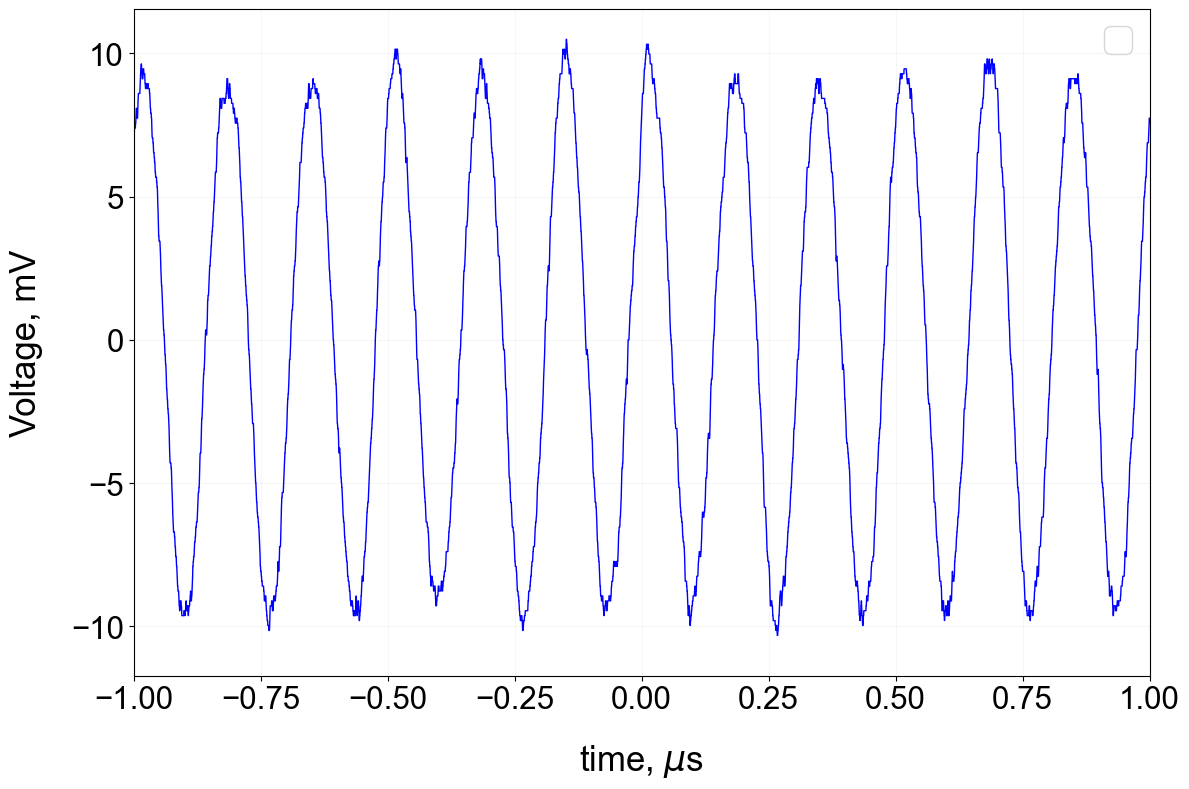

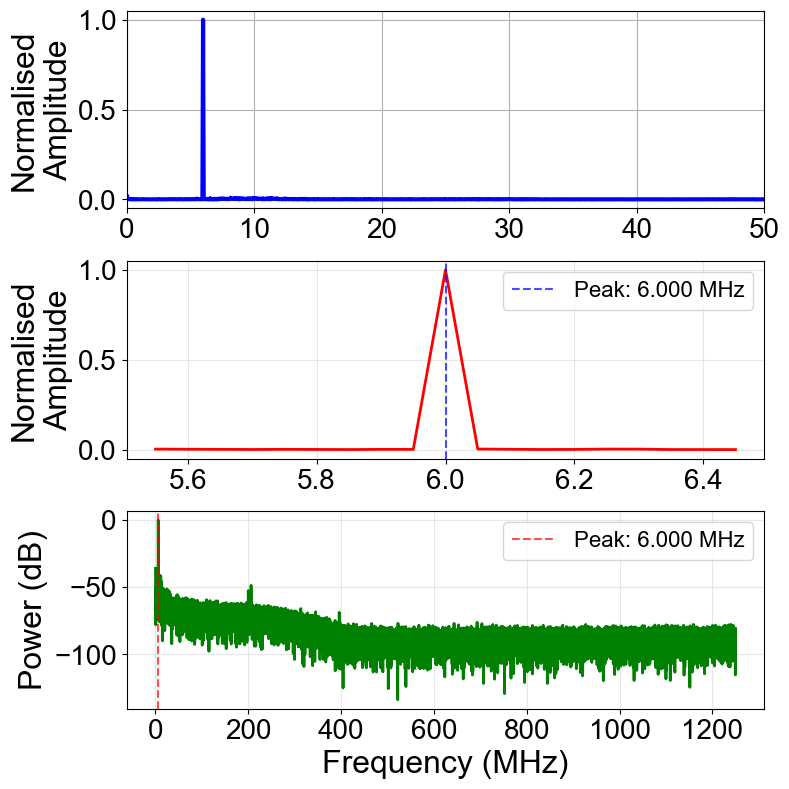

In [82]:
osci = LaserMeasurement(filename_6mhz).oscilloscope_data(plot=True, figsize=(12,8), save_fig_name= '6MHz_oscilloscope')
spec = LaserMeasurement(filename_6mhz).spectrum_data(plot = True, figsize=(8,8)) 

In [72]:
ll6 = LaserMeasurement(filename_6mhz)
# fwhm6 = ll6.linewidth(fit = 'lorentzian', freq_window = 5.00, gamma_g= 0.05, sigma_g = 0.05,figsize = (12,8))
# perf1= ll6.fit_performance(fit = 'gaussian', plot = False)
# perf2= ll6.fit_performance(fit = 'lorentzian', plot = False)
# perf3= ll6.fit_performance(fit = 'voigt', plot = False)

# print(perf1,perf2,perf3)

Gaussian 96.014 $\pm$ 0.637
Lorentzian 80.430 $\pm$ 0.186
Voigt 95.692 $\pm$ 0.129


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

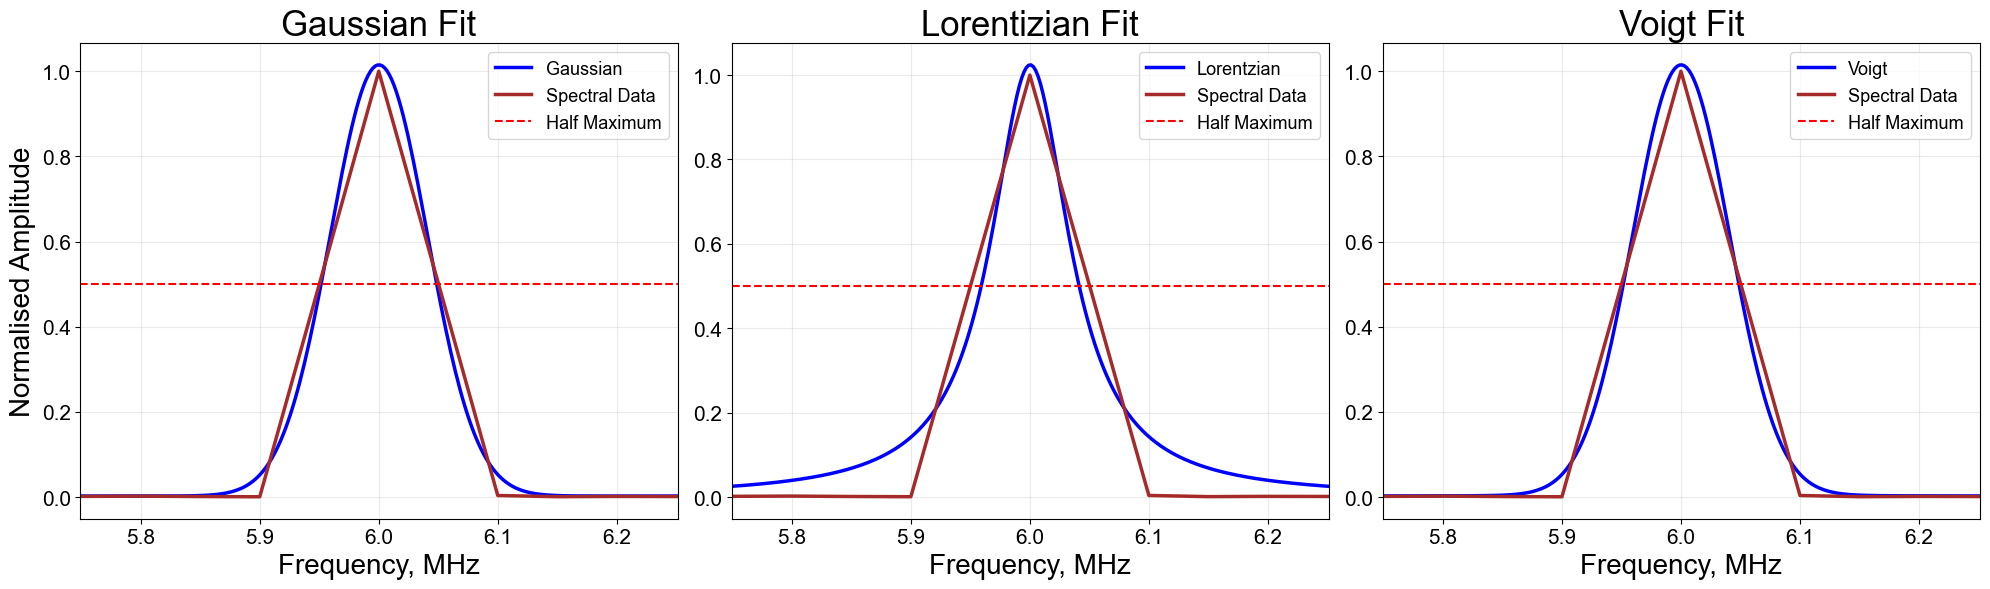

In [62]:
data_v= ll6.linewidth(fit = 'voigt', freq_window = 5.00, gamma_g= 0.05, sigma_g = 0.05,plot = False)
data_g= ll6.linewidth(fit = 'gaussian', freq_window = 5.00, gamma_g= 0.05, sigma_g = 0.05,plot = False)
data_l = ll6.linewidth(fit = 'lorentzian', freq_window = 5.00, gamma_g= 0.05, sigma_g = 0.05,plot = False)

freqs_11 = data_g['fitted_freqs_mhz']
spectrum_11 = data_g['gaussian_fit']
freqs_12 = data_g['freqs_mhz']
spectrum_12 = data_g['spectrum']
fwhm11 = data_g['fwhm']
fwhm11_err = data_g['fwhm_error']


freqs_21 = data_l['fitted_freqs_mhz']
spectrum_21 = data_l['lorentzian_fit']
freqs_22 = data_l['freqs_mhz']
spectrum_22 = data_l['spectrum']
fwhm21 = data_l['fwhm']
fwhm21_err = data_l['fwhm_error']

freqs_31 = data_v['fitted_freqs_mhz']
spectrum_31 = data_v['voigt_fit']
freqs_32 = data_v['freqs_mhz']
spectrum_32 = data_v['spectrum']
fwhm31 = data_v['fwhm']
fwhm31_err = data_v['fwhm_error']

# freqs_data = fwhm6['freqs_mhz'] 
# spectrum_data = fwhm6['spectrum']
# freqs_fitted = fwhm6['fitted_freqs_mhz'] 
# spectrum_fitted = fwhm6['voigt_fit']
# FWHM1 = fwhm6['FWHM_MHz']
f0 = fwhm6['central_frequency']
window = 1.00



# print(freqs_data)
# print(spectrum_data)
# Unpack axes directly
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

labsize = 20
ticksize = 15
titlesize = 25
lw = 2.5
lower = f0 - (window/4 +0.001)
upper = f0 + (window/4 + 0.001)

plt.rcParams['font.family'] = 'Arial'

ax1.plot(freqs_11, spectrum_11, 'b',linewidth = lw, label = "Gaussian") 
ax1.plot(freqs_12, spectrum_12, 'brown',linewidth = lw,  label="Spectral Data")
ax1.axhline(y=0.5, color='red', linestyle='--', label='Half Maximum')
ax1.legend(loc='upper right', fontsize=12)
ax1.set_xlabel("Frequency, MHz", size = labsize)
ax1.set_ylabel("Normalised Amplitude", size = labsize)
ax1.tick_params(axis='both', which='major', labelsize=ticksize)
ax1.set_xlim([lower,upper])
ax1.set_title(fr"Gaussian Fit",size = titlesize)
ax1.legend(fontsize = 13, loc='upper right', bbox_to_anchor=(1, 1))
ax1.grid(True, alpha = 0.25)

ax2.plot(freqs_21, spectrum_21, 'b', linewidth = lw, label = "Lorentzian") 
ax2.plot(freqs_22, spectrum_22, 'brown', linewidth = lw, label = "Spectral Data")
ax2.axhline(y=0.5, color='red', linestyle='--', label='Half Maximum')
ax2.set_xlabel("Frequency, MHz", size = labsize)
ax2.tick_params(axis='both', which='major', labelsize=ticksize)
ax2.set_xlim([lower,upper])
ax2.set_title(fr"Lorentizian Fit",size = titlesize)
ax2.legend(fontsize = 13, loc='upper right', bbox_to_anchor=(1, 1))
ax2.grid(True, alpha = 0.25)

ax3.plot(freqs_31, spectrum_31, 'b', linewidth = lw, label = "Voigt") 
ax3.plot(freqs_32, spectrum_32, 'brown', linewidth = lw, label = "Spectral Data")
ax3.axhline(y=0.5, color='red', linestyle='--', label='Half Maximum')
ax3.set_xlabel("Frequency, MHz", size = labsize)
ax3.tick_params(axis='both', which='major', labelsize=ticksize)
ax3.set_xlim([lower,upper])
ax3.set_title(fr"Voigt Fit",size = titlesize)
ax3.legend(fontsize = 13, loc='upper right', bbox_to_anchor=(1, 1))
ax3.grid(True, alpha = 0.25)

print(fr'Gaussian {fwhm11:.3f} $\pm$ {fwhm11_err:.3f}')
print(fr'Lorentzian {fwhm21:.3f} $\pm$ {fwhm21_err:.3f}')
print(fr'Voigt {fwhm31:.3f} $\pm$ {fwhm31_err:.3f}')
plt.tight_layout()
plt.show()

Calculated scan rate: 800.0 MHz/ms


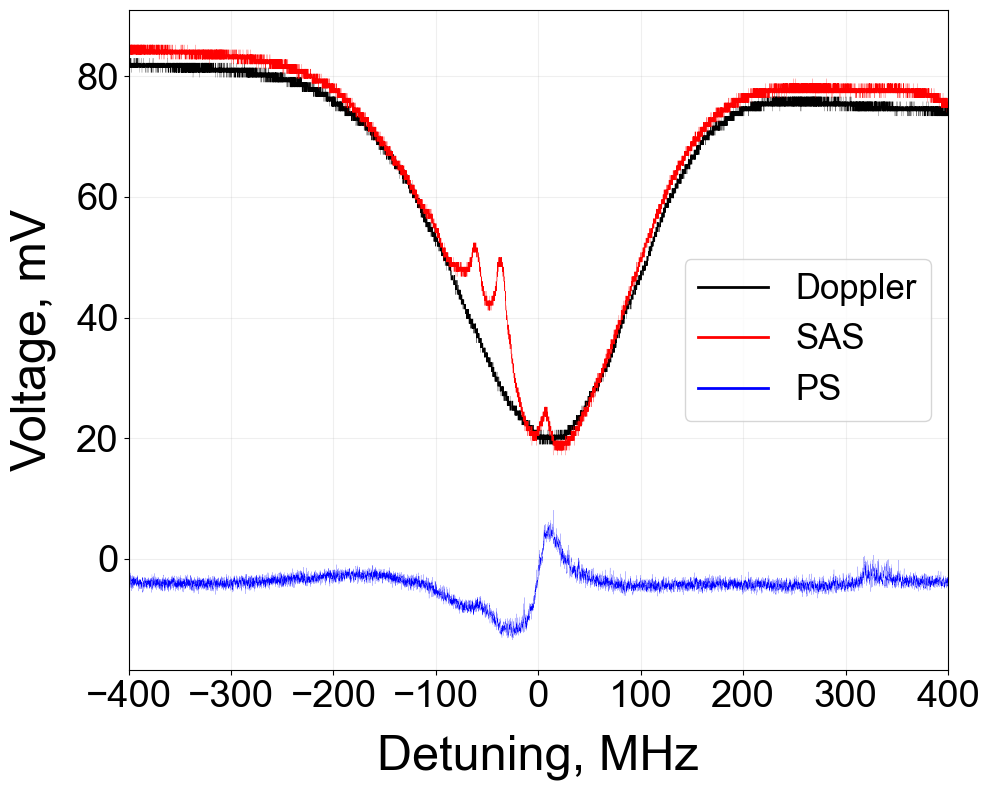

In [80]:
class AtomSpectroscopy:
    
    
    def __init__(self, 
                 dop_file, 
                 sas_file, 
                 pol_file, 
                 scan_rate_MHz_per_ms=None, 
                 zero_time_ms=0):
        
        self.dop_file = dop_file
        self.sas_file = sas_file
        self.pol_file = pol_file
        self.scan_rate = scan_rate_MHz_per_ms  # MHz/ms
        self.zero_time_ms = zero_time_ms  # Time where detuning = 0
    
    def calibrate_frequency_axis(self, 
                                 time_ms, 
                                 scan_rate_MHz_per_ms=None, 
                                 zero_time_ms=None):
        """Convert time axis to detuning frequency in MHz"""
        if scan_rate_MHz_per_ms is None:
            scan_rate_MHz_per_ms = self.scan_rate
        if zero_time_ms is None:
            zero_time_ms = self.zero_time_ms
        
        if scan_rate_MHz_per_ms is None:
            raise ValueError("Scan rate must be provided for frequency calibration")
        
        # Convert time in ms to detuning in MHz
        detuning_MHz = (time_ms - zero_time_ms) * scan_rate_MHz_per_ms
        return detuning_MHz
    
    def find_scan_rate_from_reference(self, 
                                      time_ms, 
                                      known_peak_times_ms, 
                                      known_frequency_separation_MHz):
        """Calculate scan rate from known frequency references"""
        if len(known_peak_times_ms) != 2:
            raise ValueError("Need exactly two peak times")
        
        time_separation_ms = abs(known_peak_times_ms[1] - known_peak_times_ms[0])
        scan_rate = known_frequency_separation_MHz / time_separation_ms
        return scan_rate
    
    def oscilloscope_data(self, 
        plot=True,
        figsize=(12, 8),
        smooth=True,
        window_size=51, 
        use_frequency_axis=False, 
        xlim_MHz = None,
        font_family = 'Arial',
        save_fig = True,
        save_fig_name = None):
        
        # Read CSV and validate
        df1 = pd.read_csv(self.dop_file, skiprows=11, names=['TIME', 'CH1'])
        df2 = pd.read_csv(self.sas_file, skiprows=11, names=['TIME', 'CH1'])
        df3 = pd.read_csv(self.pol_file, skiprows=11, names=['TIME', 'CH1'])

        if 'TIME' not in df1.columns or 'CH1' not in df1.columns:
            raise ValueError("Invalid CSV structure: missing TIME or CH1 columns")
        if 'TIME' not in df2.columns or 'CH1' not in df2.columns:
            raise ValueError("Invalid CSV structure: missing TIME or CH1 columns")
        if 'TIME' not in df3.columns or 'CH1' not in df3.columns:
            raise ValueError("Invalid CSV structure: missing TIME or CH1 columns")

        # Convert to numeric and clean NaNs
        time_s = pd.to_numeric(df1['TIME'], errors='coerce').dropna().values
        dop_volts = pd.to_numeric(df1['CH1'], errors='coerce').dropna().values
        sas_volts = pd.to_numeric(df2['CH1'], errors='coerce').dropna().values
        pol_volts = pd.to_numeric(df3['CH1'], errors='coerce').dropna().values

        # Convert time to milliseconds
        time_ms = time_s * 1e3

        if smooth:
            pol_volts_smooth = savgol_filter(pol_volts, window_size, 3)
        else:
            pol_volts_smooth = pol_volts

        if len(time_ms) == 0 or len(pol_volts) == 0 or len(sas_volts) == 0 or len(dop_volts) == 0:
            raise ValueError("No valid data found after cleaning")

        # Create frequency axis if requested
        if use_frequency_axis and self.scan_rate is not None:
            x_axis = self.calibrate_frequency_axis(time_ms)
            x_label = "Detuning, MHz"
            if xlim_MHz is not None:
                x_limits = xlim_MHz
            else:
                # Convert default time limits to frequency
                x_limits = self.calibrate_frequency_axis(np.array([-0.50, 0.50]))
        else:
            x_axis = time_ms
            x_label = fr"Time, $\mu$s"
            x_limits = [-0.50, 0.50] if xlim_MHz is None else xlim_MHz

        if plot:

            plt.rcParams['font.family'] = font_family
            # plt.rcParams['font.size'] = font_size
            # plt.rcParams['axes.titlesize'] = font_size
            # plt.rcParams['axes.labelsize'] = font_size
            # plt.rcParams['xtick.labelsize'] = font_size
            # plt.rcParams['ytick.labelsize'] = font_size
            # plt.rcParams['legend.fontsize'] = font_size
            # plt.rcParams['figure.titlesize'] = font_size
            
            ticksize = 27.5
            labsize = 35
            lw = 0.1
            pad = 15
            plt.figure(figsize = figsize)

            if use_frequency_axis:
                time_shifted_ms = time_ms - 0.06
                x_axis_shifted = self.calibrate_frequency_axis(time_shifted_ms)
                plt.plot(-x_axis_shifted, dop_volts * 1e3 - 65, 'black', label='Doppler', linewidth=lw)
                plt.plot(-x_axis, sas_volts * 1e3 - 80, 'r', label='SAS', linewidth=lw)
                plt.plot(-x_axis, pol_volts_smooth * 1e3, 'b', label='PS', linewidth=lw)
            
            else:
                plt.plot(time_ms - 0.06, dop_volts * 1e3 - 65, 'black', label='Doppler', linewidth=lw)
                plt.plot(time_ms, sas_volts * 1e3 - 80, 'r', label='SAS', linewidth=lw)
                plt.plot(time_ms, pol_volts_smooth * 1e3, 'b', label='PS', linewidth=lw)
                
            plt.xlabel("Detuning, MHz", size = labsize,labelpad=pad)
            plt.ylabel("Voltage, mV", size = labsize, labelpad= pad)
            plt.xticks(size = ticksize)
            plt.yticks(size = ticksize)
            plt.xlim(x_limits)
            plt.legend(fontsize = labsize-10)
            plt.grid(True, alpha = 0.2)

            for line in plt.legend(fontsize = labsize -10).get_lines():
                line.set_linewidth(2.0)

            plt.tight_layout()
            

            if save_fig:
                if save_fig_name is None:
                    # Generate timestamp with year-month-day and seconds
                    timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
                    save_figure_name = f"Spectroscopy_{timestamp}.png"
                else:
                    save_figure_name = save_fig_name
                
                plt.savefig(save_figure_name, bbox_inches = 'tight', pad_inches = 0.2, dpi = 600)
            
            plt.show()


        return {
            "time_data": time_ms,
            "frequency_data": x_axis if use_frequency_axis else None,
            "doppler_data": dop_volts,
            "sas_data": sas_volts,
            "ps_data": pol_volts_smooth,
            "scan_rate": self.scan_rate
        }

# Example usage with frequency calibration:
dop = 'data/atom_spectroscopy/dop_000.csv'
sas = 'data/atom_spectroscopy/sas_000.csv'
pol = 'data/atom_spectroscopy/pol_000.csv'

# Method 1: If you know the scan rate directly (e.g., 800 MHz/ms)
# spec = AtomSpectroscopy(dop, sas, pol, scan_rate_MHz_per_ms=800, zero_time_ms=0)
# data = spec.oscilloscope_data(plot=True, smooth=True, figsize=(10,8), 
#                              use_frequency_axis=True, xlim_MHz=[-400, 400])

# Method 2: If you need to calculate scan rate from known peaks
# For example, if you have two SAS peaks at t1 = -0.2 ms and t2 = 0.2 ms 
# that correspond to a known 320 MHz separation:
spec = AtomSpectroscopy(dop, sas,pol)
scan_rate = spec.find_scan_rate_from_reference(
    data["time_data"], 
    known_peak_times_ms=[-0.2, 0.2], 
    known_frequency_separation_MHz=320
)
print(f"Calculated scan rate: {scan_rate:.1f} MHz/ms")

# Now use this calculated scan rate
spec.scan_rate = scan_rate
data_calibrated = spec.oscilloscope_data(plot=True, 
                                         smooth=True, 
                                         figsize=(10,8), 
                                         use_frequency_axis=True,
                                         save_fig= False,
                                         save_fig_name='spec_peaks_freq.png')

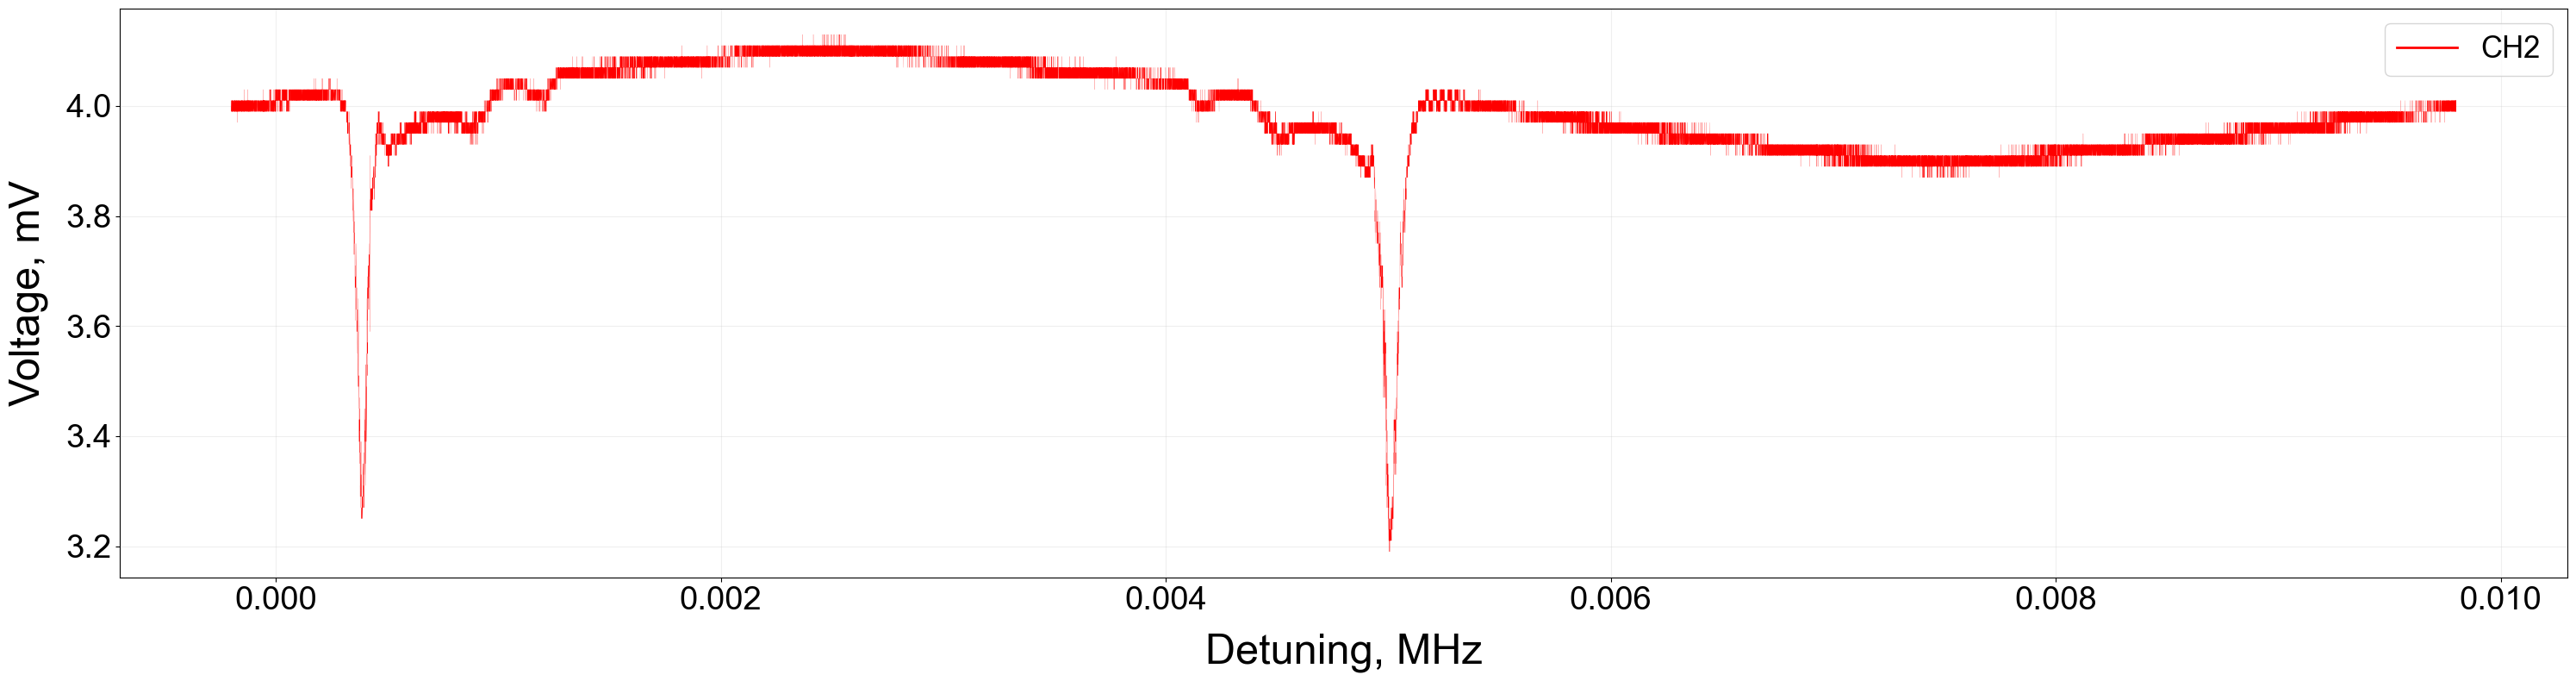

In [136]:
t1 = 'data/mot_thermal/thermo1_000_ALL.csv'   
t2 = 'data/mot_thermal/thermo2_000_ALL.csv'   
t3 = 'data/mot_thermal/thermo3_000_ALL.csv'   
t4 = 'data/mot_thermal/thermo4_000_ALL.csv'   
t5 = 'data/mot_thermal/thermo5_000_ALL.csv'
t6 = 'data/mot_thermal/thermo6_000_ALL.csv'   
t7 = 'data/mot_thermal/thermo7_000_ALL.csv'   

class ColdAtomSpectroscopy:


    def __init__(self,f1,f2,f3,f4,f5,f6,f7):
        self.f1 = f1
        self.f2 = f2
        self.f3 = f3
        self.f4 = f4
        self.f5 = f5
        self.f6 = f6
        self.f7 = f7

    def oscilloscope_data(self,
        index, 
        plot=True,
        figsize=(12, 8),
        use_frequency_axis=False, 
        xlim_MHz = None,
        font_family = 'Arial',
        save_fig = True,
        save_fig_name = None
        ):

        # Read CSV and validate
        df1 = pd.read_csv(self.f1, skiprows=14, names=['TIME', 'CH1', 'CH2', 'CH3'])
        df2 = pd.read_csv(self.f2, skiprows=14, names=['TIME', 'CH1', 'CH2', 'CH3'])
        df3 = pd.read_csv(self.f3, skiprows=14, names=['TIME', 'CH1', 'CH2', 'CH3'])
        df4 = pd.read_csv(self.f4, skiprows=14, names=['TIME', 'CH1', 'CH2', 'CH3'])
        df5 = pd.read_csv(self.f5, skiprows=14, names=['TIME', 'CH1', 'CH2', 'CH3'])
        df6 = pd.read_csv(self.f6, skiprows=14, names=['TIME', 'CH1', 'CH2', 'CH3'])
        df7 = pd.read_csv(self.f7, skiprows=14, names=['TIME', 'CH1', 'CH2', 'CH3'])

        df_packed = [df1,df2,df3,df4,df5,df6,df7]
        cols = ['TIME','CH1','CH2','CH3']

        time_data = []
        ch1_data = []
        ch2_data= []
        ch3_data = []

        

        for i,df in enumerate(df_packed,1):
            time_data.append(pd.to_numeric(df['TIME'], errors = 'coerce').dropna().values)
            ch1_data.append(pd.to_numeric(df['CH1'], errors = 'coerce').dropna().values)
            ch2_data.append(pd.to_numeric(df['CH2'], errors = 'coerce').dropna().values)
            ch3_data.append(pd.to_numeric(df['CH3'], errors = 'coerce').dropna().values)
            for col in cols:
                if col not in df.columns:
                    raise ValueError("Invalid CSV structure in file {i}: missing {col} columns")


        


        if plot:

            plt.rcParams['font.family'] = font_family
            # plt.rcParams['font.size'] = font_size
            # plt.rcParams['axes.titlesize'] = font_size
            # plt.rcParams['axes.labelsize'] = font_size
            # plt.rcParams['xtick.labelsize'] = font_size
            # plt.rcParams['ytick.labelsize'] = font_size
            # plt.rcParams['legend.fontsize'] = font_size
            # plt.rcParams['figure.titlesize'] = font_size
            
            ticksize = 27.5
            labsize = 35
            lw = 0.1
            pad = 15
            plt.figure(figsize = figsize)

            # plt.plot(time_data[index],ch1_data[index], 'black', label='CH1', linewidth=lw)
            plt.plot(time_data[index],ch2_data[index], 'r', label='CH2', linewidth=lw)
            # plt.plot(time_data[index],ch3_data[index], 'b', label='CH3', linewidth=lw)
                
            plt.xlabel("Detuning, MHz", size = labsize,labelpad=pad)
            plt.ylabel("Voltage, mV", size = labsize, labelpad= pad)
            plt.xticks(size = ticksize)
            plt.yticks(size = ticksize)
            # plt.xlim(x_limits)
            plt.legend(fontsize = labsize-10)
            plt.grid(True, alpha = 0.2)

            for line in plt.legend(fontsize = labsize -10).get_lines():
                line.set_linewidth(2.0)

            plt.tight_layout()
            

            if save_fig:
                if save_fig_name is None:
                    # Generate timestamp with year-month-day and seconds
                    timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
                    save_figure_name = f"Spectroscopy_{timestamp}.png"
                else:
                    save_figure_name = save_fig_name
                
                plt.savefig(save_figure_name, bbox_inches = 'tight', pad_inches = 0.2, dpi = 600)
            
            plt.show()



        return {
            'time_data': time_data, 
            'ch1_data': ch1_data, 
            'ch2_data': ch2_data, 
            'ch3_data': ch3_data
        }
    

        # if 'TIME' not in df1.columns or 'CH1' not in df1.columns :
        #     raise ValueError("Invalid CSV structure: missing TIME or CH1 columns")
        # if 'TIME' not in df2.columns or 'CH1' not in df2.columns:
        #     raise ValueError("Invalid CSV structure: missing TIME or CH1 columns")
        # if 'TIME' not in df3.columns or 'CH1' not in df3.columns:
        #     raise ValueError("Invalid CSV structure: missing TIME or CH1 columns")


cas = ColdAtomSpectroscopy(t1,t2,t3,t4,t5,t6,t7)
index = 3
cas.oscilloscope_data(index = index, figsize = (30,8));

        
